# Predicción de Suscripción a un Depósito Bancario

- Manuel Manchado Barquero (NIA: 100522228)
- David Mateu Serrano (NIA: 100522337)

[Repositorio Github](https://github.com/100522228/P1_Machine_learning.git)

## EDA
En esta sección realizamos un análisis técnico de los datos para determinar la estrategia de preprocesamiento. El objetivo es identificar la naturaleza de las variables y posibles problemas en el dataset.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# Establecemos la semilla para permitir reproducir los resultados
SEED = 100522228
target = 'deposit' # Dejamos creada la variable que se usará más adelante

# Leemos los datos
file_path = Path("content/P1") / "bank_10.pkl"
df = pd.read_pickle(file_path)

# Identificamos el número de instancias y variables
n_instancias, n_variables = df.shape
print(f"El dataset contiene {n_instancias} instancias y {n_variables} variables.")
# Ya que deposit solo contiene los valores si o no, nos encontramos ante un problema de clasificación binaria
print(f"Tipo de problema: Clasificación binaria (Target: '{target}')")

# Vamos a recorrer todas las variables para sacar la información necesaria de cada una
# Listas para clasificar los distintos tipos de datos (las ordinales las introducimos por conocimiento propio, ya que no se pueden distinguir a simple vista de las categóricas)
var_ordinales = ['education', 'month']
var_numericas = []
var_categoricas = []

for col in df.columns:
    if col == target:
        continue
    # Vamos clasificando las variables que nos quedan (numéricas y categóricas)
    if np.issubdtype(df[col].dtype, np.number):
        var_numericas.append(col)
    elif col in var_ordinales:
        continue # Ya está en la lista de ordinales
    else:
        var_categoricas.append(col)

# Una vez que tenemos los tipos de las variables, identificamos la alta cardinalidad (solamente para variables categóricas), las ctes y los ID
alta_cardinalidad = []
columnas_constantes = []
columnas_id = []

# Mostramos los resultados a modo de tabla
print(f"\n{'COLUMNA':<15} | {'TIPO':<10} | {'ÚNICOS':<7} | {'NaN (%)':<12} | {'UNKNOWN (%)':<12}")
print("-" * 75)

for col in df.columns:
    # Además, identificamos los valores únicos (solo para los categóricos), los Nan y los unknown
    n_nan = df[col].isna().sum()
    n_unknown = (df[col] == 'unknown').sum() if df[col].dtype == 'object' else 0
    n_unicos = df[col].nunique()

    # Calculamos porcentajes
    pct_nan = (n_nan / n_instancias) * 100
    pct_unknown = (n_unknown / n_instancias) * 100
    
    # Preparamos los strings de visualización: "cantidad (porcentaje%)"
    nan_display = f"{n_nan} ({pct_nan:.1f}%)"
    unknown_display = f"{n_unknown} ({pct_unknown:.1f}%)"

    
    # Determinamos la etiqueta del tipo
    if col == target:
        tipo_str = "TARGET"
        unicos_display = str(n_unicos)
    elif col in var_numericas:
        tipo_str = "Numérica"
        unicos_display = "-" # No tiene sentido mostrar los valores únicos de una variable numérica
    elif col in var_ordinales:
        tipo_str = "Ordinal"
        unicos_display = str(n_unicos)
        if n_unicos > 10:
            alta_cardinalidad.append(col)
    else:
        tipo_str = "Categórica"
        unicos_display = str(n_unicos)
        if n_unicos > 10:
            alta_cardinalidad.append(col)

   # Imprimimos la información con el nuevo formato
    print(f"{col:<15} | {tipo_str:<10} | {unicos_display:<7} | {nan_display:<12} | {unknown_display:<12}")

    # Comprobaciones de integridad (ctes o ID)
    if col != target:
        if n_unicos <= 1:
            columnas_constantes.append(col)
        if n_unicos == n_instancias:
            columnas_id.append(col)

print("-" * 65)

# Imprimimos los resultados adicionales
print(f"\nVariables con alta cardinalidad (>10): {alta_cardinalidad}")
print(f"Columnas constantes: {columnas_constantes}")
print(f"Columnas tipo ID: {columnas_id}")


# Ahora comprobamos el balanceo de deposit. Nuestro objetivo es identificar un posible desbalanceo
counts = df[target].value_counts()
percentages = df[target].value_counts(normalize=True) * 100

print(f"\nBalanceo de la clase '{target}':")
for index in counts.index:
    print(f"{index}: {counts[index]} ({percentages[index]:.2f}%)")

# Realizamos el preprocesado de la variable Pdays (ya que no hay riesgo de data leakage)
n_minus_one = (df['pdays'] == -1).sum()
print(f"\nAnálisis de 'pdays': {n_minus_one} instancias con -1 ({n_minus_one/n_instancias:.2%})")

# Creamos una nueva variable (a continuacíon se incluye una explicación de esta decisión)
df['pdays_contacted'] = (df['pdays'] != -1).astype(int) 
df['pdays'] = df['pdays'].replace(-1, 0)


El dataset contiene 11000 instancias y 17 variables.
Tipo de problema: Clasificación binaria (Target: 'deposit')

COLUMNA         | TIPO       | ÚNICOS  | NaN (%)      | UNKNOWN (%) 
---------------------------------------------------------------------------
age             | Numérica   | -       | 0 (0.0%)     | 0 (0.0%)    
job             | Categórica | 12      | 332 (3.0%)   | 66 (0.6%)   
marital         | Categórica | 3       | 183 (1.7%)   | 0 (0.0%)    
education       | Ordinal    | 4       | 0 (0.0%)     | 494 (4.5%)  
default         | Categórica | 2       | 0 (0.0%)     | 0 (0.0%)    
balance         | Numérica   | -       | 0 (0.0%)     | 0 (0.0%)    
housing         | Categórica | 2       | 0 (0.0%)     | 0 (0.0%)    
loan            | Categórica | 2       | 0 (0.0%)     | 0 (0.0%)    
contact         | Categórica | 3       | 0 (0.0%)     | 2309 (21.0%)
day             | Numérica   | -       | 0 (0.0%)     | 0 (0.0%)    
month           | Ordinal    | 12      | 0 (0.0%)  

En cuanto a la calidad y el tipo de variables, no se han encontrado columnas que sean constantes ni identificadores únicos. Aun así, hay que tener en cuenta que algunas variables, como *job* y *month*, tienen una cardinalidad bastante alta (más de 10 valores distintos). También aparecen valores *unknown* en varias variables, como *poutcome*, *contact* o *education*, entre otras.

En lo que respecta a la variable objetivo, los datos están bastante equilibrados: aproximadamente un 52,55% corresponden a la clase "no" y un 47,45% a la clase "yes".

Por otro lado, la variable *pdays* tiene una característica importante: cerca del 74,57% de los registros tienen el valor -1. Es clave tratar este detalle mediante el preprocesado, el cual, no se basa en cálculos globales como medias o modas, sino en el propio significado de los datos, por ello, no hay riesgo de introducir *data leakage*.

En el preprocesado, primero, se ha creado una nueva variable llamada *pdays_contacted*, que indica si el cliente ha sido contactado antes, vale 1 si sí lo ha sido, y 0 en caso de no contacto o en caso desconocido. Esto ayuda al modelo a captar rápidamente si existe ese historial previo sin tener que recurrir a *pdays*. Además, en la variable original *pdays*, se han sustituido los valores -1 por 0. Así, la variable pasa a tener únicamente valores numéricos coherentes, representando el tiempo desde el último contacto. Con esto evitamos problemas donde un -1 podría interpretarse como un valor menor que 0 días y afectar a los resultados.


## Definición evaluación

Para la evaluación externa usaremos un Holdout dividiendo los datos en 2/3 para entrenamiento y 1/3 para test. Dado que las clases de la variable deposit están balanceadas, el Accuracy es una métrica robusta para medir el rendimiento real. 

In [27]:
from sklearn.model_selection import train_test_split

# Convertimos el target a numérico: 'yes' -> 1, 'no' -> 0 (si no hacemos esto, al usar Optuna nos dará error)
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

# Definimos X (predictores) e y (objetivo) 
X = df.drop(columns=[target])
y = df[target]

# Realizamos el split 1/3 para test y 2/3 para entrenamiento
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.33, 
    random_state=SEED, 
    stratify=y # Mantiene la proporción de la clase 'deposit'
)


## Métodos básicos: KNN y Trees

### Elección método de escalado

Antes de comenzar a probar distintos modelos, es necesario determinar el método de escalado más adecuado utilizando KNN como referencia, integrando todo el preprocesamiento en Pipelines para evitar el data leakage. 

Dado que este algoritmo se basa en distancias y no puede tratar con valores no numéricos, las variables numéricas se imputan con la mediana para mitigar el efecto de los datos atípicos, mientras que las categóricas se procesan mediante One-Hot Encoding e imputación constante con la etiqueta "unknown". De forma silimar, las variables ordinales se procesan con un Ordinal Encoder e imputación constante con la etiqueta "unknown". Esta elección permite tratar la ausencia de datos como una categoría informativa independiente, lo cual es fundamental dado el alto volumen de valores "unknown" detectados en el EDA que podrían aportar información útil sobre el comportamiento del cliente. De esta manera, tratamos de manera similar la etiqueta unknown a si se encuentra un NaN, vamos a suponer que en cualquiera de los dos casos, el cliente decidió no espeficiarlo y justo eso es lo que vamos a usar como una posible fuente de información.

Finalmente, siguiendo el esquema de la práctica, se utiliza una validación cruzada (3-fold CV) para comparar el rendimiento de los escaladores Standard, MinMax y Robust.

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier

# Definimos el orden para el transformer del ordinal. 
# Añadimos la categoría unknown como una posible opción
educ_order = ['unknown', 'primary', 'secondary', 'tertiary']
month_order = ['unknown', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Definimos el preprocesador base (Imputación + Encoding)
# Usamos la mediana para números y un valor constante para categorías
num_transformer_std = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

num_transformer_minmax = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

num_transformer_robust = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

ord_transformer_std = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')), 
    ('ordinal', OrdinalEncoder(
        categories=[educ_order, month_order], 
        handle_unknown='use_encoded_value', 
        unknown_value=-1
    )),
    ('scaler', StandardScaler())
])

ord_transformer_minmax = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')), 
    ('ordinal', OrdinalEncoder(
        categories=[educ_order, month_order], 
        handle_unknown='use_encoded_value', 
        unknown_value=-1
    )),
    ('scaler', MinMaxScaler())
])

ord_transformer_robust = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')), 
    ('ordinal', OrdinalEncoder(
        categories=[educ_order, month_order], 
        handle_unknown='use_encoded_value', 
        unknown_value=-1
    )),
    ('scaler', RobustScaler())

])

# 3. Construimos el preprocessor base
# --- PREPROCESADOR STANDARD ---
preprocessor_std = ColumnTransformer(transformers=[
    ('num', num_transformer_std, var_numericas),
    ('cat', cat_transformer, var_categoricas),
    ('ord', ord_transformer, var_ordinales) 
])

# --- PREPROCESADOR MINMAX ---
preprocessor_minmax = ColumnTransformer(transformers=[
    ('num', num_transformer_minmax, var_numericas),
    ('cat', cat_transformer, var_categoricas),
    ('ord', ord_transformer, var_ordinales) 
])

# --- PREPROCESADOR ROBUST ---
preprocessor_robust = ColumnTransformer(transformers=[
    ('num', num_transformer_robust, var_numericas),
    ('cat', cat_transformer, var_categoricas),
    ('ord', ord_transformer, var_ordinales) 
])

# Configuramos la validación cruzada (como se indica en el esquema)
cv_inner = KFold(n_splits=3, shuffle=True, random_state=SEED)

# Probamos los 3 escaladores con KNN HP por defecto
preprocessors = {
    'StandardScaler': preprocessor_std,
    'MinMaxScaler': preprocessor_minmax,
    'RobustScaler': preprocessor_robust
}

results = {}

print(f"{'Escalador':<20} | {'Accuracy':<15}")
print("-" * 50)

for name, prep in preprocessors.items():
    # El pipeline ahora solo tiene: Preproceso (que ya escala) -> Modelo
    pipeline = Pipeline(steps=[
        ('pre', prep),
        ('knn', KNeighborsClassifier())
    ])
    
    # Evaluación mediante validación cruzada sobre el bloque de TRAIN
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv_inner, scoring='accuracy')
    
    results[name] = scores.mean()
    print(f"{name:<20} | {scores.mean():.4f}")

# Seleccionamos el ganador para usarlo de aquí en adelante (el que tenga más accuracy)
best_scaler_name = max(results, key=results.get)
best_scaler_obj = scalers[best_scaler_name]

print(f"\nEl mejor método de escalado es: {best_scaler_name}")

Escalador            | Accuracy       
--------------------------------------------------
StandardScaler       | 0.8030
MinMaxScaler         | 0.7141
RobustScaler         | 0.7938

El mejor método de escalado es: StandardScaler


### Evaluación con HP por defecto

Tras seleccionar el escalador óptimo, procedemos a evaluar el rendimiento base de los modelos KNN y Árbol de Decisión utilizando sus hiperparámetros por defecto y midiendo el tiempo de entrenamiento. 

Para evitar el data leakage, integramos nuevamente el preprocesamiento dentro de los Pipelines, asegurando que tanto la imputación por mediana como el One-Hot Encoding se ajusten exclusivamente en el conjunto de entrenamiento de cada iteración. 

In [29]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# Creamos un diccionario vacío para almacenar los resultados (los usaremos luego en las conclusiones también)
resultados_defecto = {}

# Definimos los modelos con sus Pipelines
# Usamos el RobustScaler para KNN según los resultados anteriores 
knn_pipeline = Pipeline(steps=[
    ('pre', preprocessor_std),
    ('model', KNeighborsClassifier())
])

tree_pipeline = Pipeline(steps=[
    ('pre', preprocessor_std),
    ('model', DecisionTreeClassifier(random_state=SEED))
])

modelos = {
    'KNN': knn_pipeline,
    'Árbol de Decisión': tree_pipeline
}

# Tabla
print(f"{'Modelo':<28} | {'Accuracy':<15} | {'Tiempo Train'}")
print("-" * 65)

# Evaluación y medición
for nombre, pipe in modelos.items():
    # Medimos el tiempo de entrenamiento (fit) sobre el conjunto X_train 
    inicio = time.time()
    pipe.fit(X_train, y_train)
    tiempo_train = time.time() - inicio
    
    # Calculamos el accuracy mediante CV
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_inner, scoring='accuracy')
    mean_accuracy = scores.mean()
    
    # 2. GUARDAMOS los datos en el diccionario para uso posterior
    resultados_defecto[nombre] = {
        'accuracy': mean_accuracy,
        'tiempo': tiempo_train
    }
    
    # Imprimimos la fila
    print(f"{nombre:<28} | {mean_accuracy:.4f}          | {tiempo_train:.4f}s")

Modelo                       | Accuracy        | Tiempo Train
-----------------------------------------------------------------
KNN                          | 0.8030          | 0.0501s
Árbol de Decisión            | 0.7779          | 0.1223s


### Árbol de baja profundidad

A continuación, vamos a hacer uso de un árbol de decisión de baja profundidad (profundidad 3) para aprovechar su capacidad de visualización. Esto nos permitirá identificar de forma directa los atributos más relevantes y comprender las decisiones críticas que determinan la suscripción del cliente.

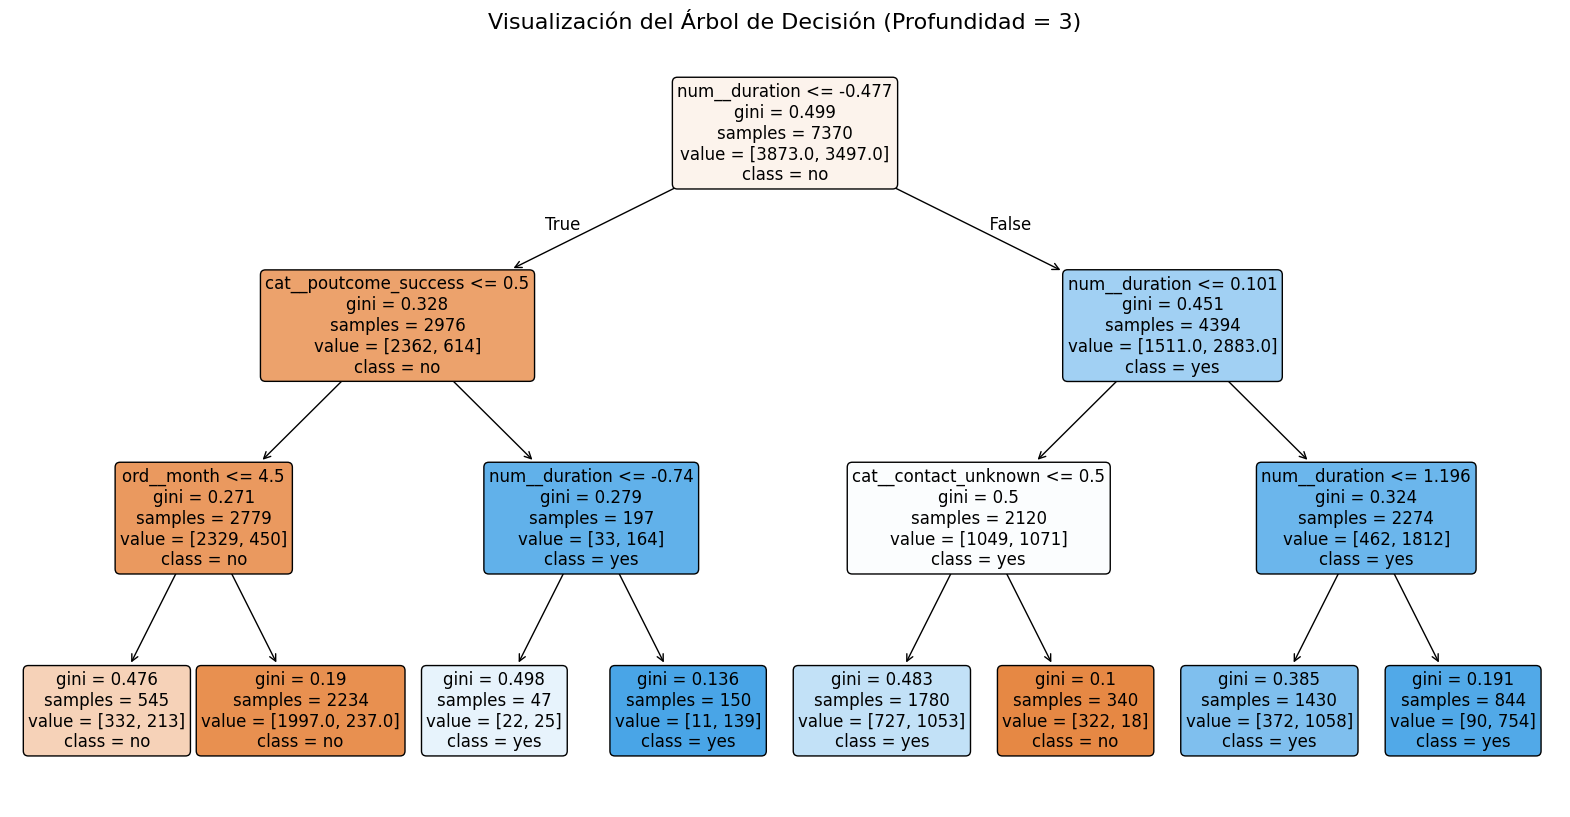

In [30]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Creamos un Pipeline específico para el árbol de poca profundidad
tree_interp_pipe = Pipeline(steps=[
    ('pre', preprocessor_std),
    ('model', DecisionTreeClassifier(max_depth=3, random_state=SEED))
])

# Hacemos fit con el conjunto X_train
tree_interp_pipe.fit(X_train, y_train)

# Visualización del árbol
plt.figure(figsize=(20, 10))
plot_tree(
    tree_interp_pipe.named_steps['model'],
    feature_names=tree_interp_pipe.named_steps['pre'].get_feature_names_out(),
    class_names=['no', 'yes'],
    filled=True, 
    rounded=True, 
    fontsize=12
)
plt.title("Visualización del Árbol de Decisión (Profundidad = 3)", fontsize=16)
plt.show()

La estructura del árbol revela que la duración de la llamada (duration) es el factor determinante, situando el umbral crítico en los 443 segundos. Las llamadas que superan este tiempo derivan en una probabilidad de suscripción significativamente mayor.

En un segundo nivel, el modelo prioriza el éxito en campañas anteriores (poutcome_success). Se observa que un historial positivo de suscripción aumenta drásticamente las posibilidades de éxito actual, incluso cuando la duración de la llamada es breve.

En conclusión, el modelo se apoya más en el comportamiento y la interacción directa que en rasgos puramente demográficos.

### Optimización (HPO)

Ahora es momento de realizar el ajuste de hiperparámetros. Para ello se va a usar Optuna, el cual es un método más eficiente que grid search o random search, ya que deja de explorar configuraciones mediocres y se centra en las prometedoras, consiguiendo mejores resultados en mucho menos tiempo. 

In [31]:
import optuna.integration
from optuna.distributions import IntDistribution as IntDist
from optuna.distributions import CategoricalDistribution as CatDist # Necesitas importar esto
from sklearn import metrics

# Lo añadimos para limpar la salida y que no haya tanto texto
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Definimos los pipelines completos para que Optuna los procese internamente
pipe_knn = Pipeline(steps=[
    ('pre', preprocessor_std),
    ('model', KNeighborsClassifier())
])

pipe_tree = Pipeline(steps=[
    ('pre', preprocessor_std),
    ('model', DecisionTreeClassifier(random_state=SEED))
])

# Definimos los hiperparámetros que queremos optimizar de cada modelo.
param_grid_knn = {
    'model__n_neighbors': IntDist(1, 51, step=2),
    'model__weights': CatDist(['uniform', 'distance']),
    'model__p': IntDist(1, 2),
    'model__leaf_size': IntDist(20, 50)
}

param_grid_tree = {
    'model__max_depth': IntDist(2, 30),
    'model__min_samples_split': IntDist(2, 30),
    'model__min_samples_leaf': IntDist(1, 15), # Número minimo de samples para ser un nodo hoja
    'model__criterion': CatDist(['gini', 'entropy']),
}

budget = 50

# Comenzamos la optimización para KNN
optuna_knn = optuna.integration.OptunaSearchCV(
    pipe_knn,
    param_grid_knn,
    scoring='accuracy',  
    n_trials=budget,
    cv=cv_inner,
    n_jobs=1, 
    verbose=1,
    timeout=600,
    random_state=SEED,
)

# Controlamos el tiempo
start_time = time.time()
optuna_knn.fit(X_train, y_train)
tiempo_knn = time.time() - start_time

# Comenzamos la optimización para el árbol
optuna_tree = optuna.integration.OptunaSearchCV(
    pipe_tree,
    param_grid_tree,
    scoring='accuracy',
    n_trials=budget,
    cv=cv_inner,
    n_jobs=1, 
    verbose=1,
    timeout=600,
    random_state=SEED,
)

# Controlamos el tiempo
start_time = time.time()
optuna_tree.fit(X_train, y_train)
tiempo_tree = time.time() - start_time

# Creamos un diccionario con los resultados de ambos modelos
resultados = {
    "Modelo": ["K-Nearest Neighbors", "Decision Tree"],
    "Mejor Accuracy (CV)": [optuna_knn.best_score_, optuna_tree.best_score_],
    "Tiempo ejecución": [f"{tiempo_knn:.2f}s", f"{tiempo_tree:.2f}s"],
    "Mejores Parámetros": [optuna_knn.best_params_, optuna_tree.best_params_]
}

# Mostramos los resultados en forma de dataframe
pd.set_option('display.max_colwidth', None) # Esto permite que se lean todos los parámetros óptimos y que no salgan cortados
df_resumen = pd.DataFrame(resultados)
display(df_resumen.sort_values(by="Mejor Accuracy (CV)", ascending=False).reset_index(drop=True))

/tmp/ipykernel_5032/1716114606.py:38: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_knn = optuna.integration.OptunaSearchCV(
/tmp/ipykernel_5032/1716114606.py:56: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_tree = optuna.integration.OptunaSearchCV(


,Modelo,Mejor Accuracy (CV),Tiempo ejecución,Mejores Parámetros
0,Decision Tree,0.814515,9.83s,"{'model__max_depth': 11, 'model__min_samples_split': 24, 'model__min_samples_leaf': 12, 'model__criterion': 'gini'}"
1,K-Nearest Neighbors,0.812618,17.37s,"{'model__n_neighbors': 19, 'model__weights': 'distance', 'model__p': 2, 'model__leaf_size': 25}"


A continuación se muestra el impacto de cada hiperparámetro probado en el rendimiento del modelo mediante plots.


Análisis de Hiperparámetros para K-Nearest Neighbors:


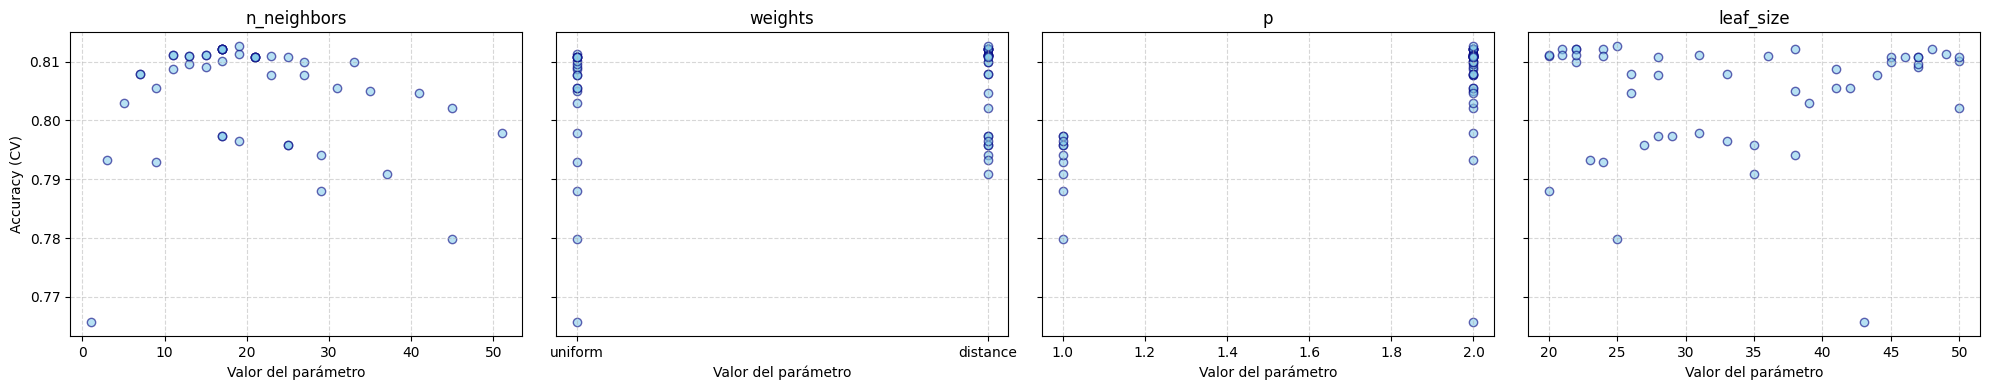


Análisis de Hiperparámetros para Decision Tree:


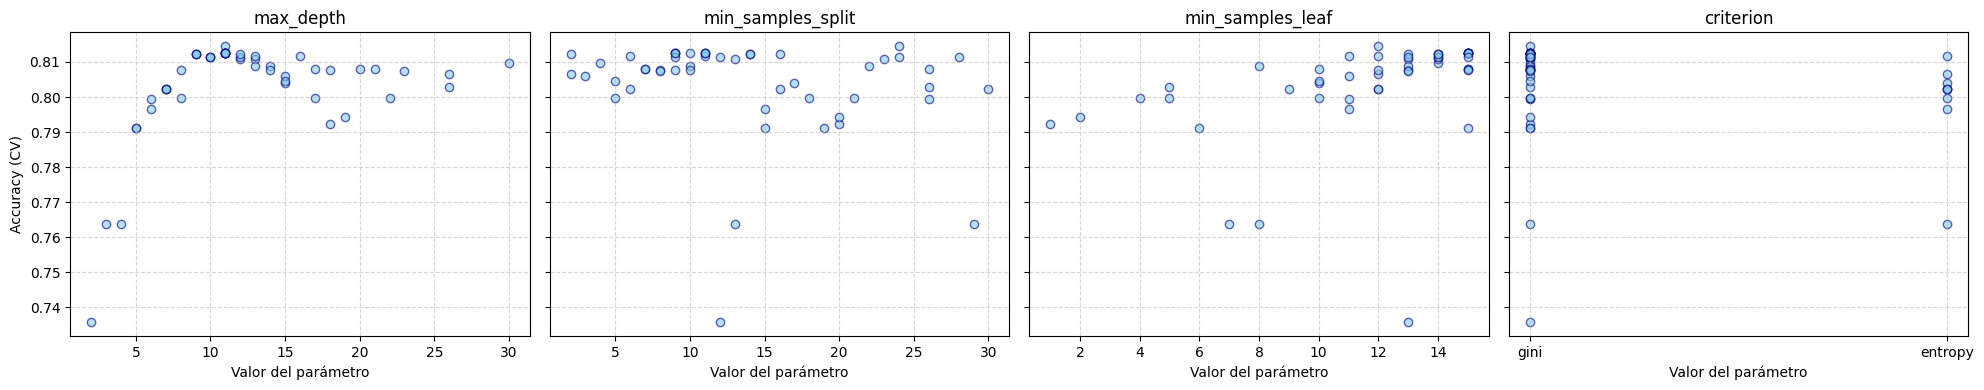

In [32]:
import matplotlib.pyplot as plt
import optuna.visualization as vis

# Extraemos los objetos 'study' de Optuna (los vamos a usar para mostrar los gráficos)
study_knn = optuna_knn.study_
study_tree = optuna_tree.study_

# Creamos una función auxiliar para crear gráficos individuales por parámetro
def plot_parameter(study, model_name):
    # Obtenemos los nombres de los parámetros probados
    params = study.best_params.keys()
    
    # Configuramos el layout de los subplots
    n_params = len(params)
    fig, axes = plt.subplots(1, n_params, figsize=(5 * n_params, 4), sharey=True)
    if n_params == 1: 
        axes = [axes]
    
    print(f"\nAnálisis de Hiperparámetros para {model_name}:")
    
    # Creamos un scatter plot por cada parámetro
    trials_df = study.trials_dataframe()
    
    for i, p in enumerate(params):
        col_name = f"params_{p}"
        axes[i].scatter(trials_df[col_name], trials_df["value"], color='skyblue', alpha=0.6, edgecolors='navy')
        axes[i].set_title(f"{p.replace('model__', '')}")
        axes[i].set_xlabel("Valor del parámetro")
        if i == 0: axes[i].set_ylabel("Accuracy (CV)")
        axes[i].grid(True, linestyle='--', alpha=0.5)
        
    plt.tight_layout()
    plt.show()

# 3. Generamos los gráficos
plot_parameter(study_knn, "K-Nearest Neighbors")
plot_parameter(study_tree, "Decision Tree")

### Conclusiones: Métodos Básicos (KNN y Árboles)

Para las conclusiones enfrentaremos un modelo trivial (Dummy) contra los modelos de KNN y Árbol de Decisión. Esta comparativa incluye tanto las versiones base de los modelos como las versiones optimizadas mediante HPO, permitiéndonos evaluar si el aumento en la precisión compensa el mayor coste computacional.

En este análisis final, se hace una distinción entre el tiempo dedicado al entrenamiento del modelo con los parámetros ya optimizados y el tiempo consumido por el proceso de búsqueda.

,Modelo,Accuracy,Tiempo HPO (s),Tiempo Entrenamiento (s)
0,Árbol (Optimizado),0.814515,9.827348,0.081730
1,KNN (Optimizado),0.812618,17.373590,0.037771
2,KNN (Defecto),0.802984,0.000000,0.050105
3,Árbol (Defecto),0.777883,0.000000,0.122292
4,Dummy,0.525509,0.000000,0.028890


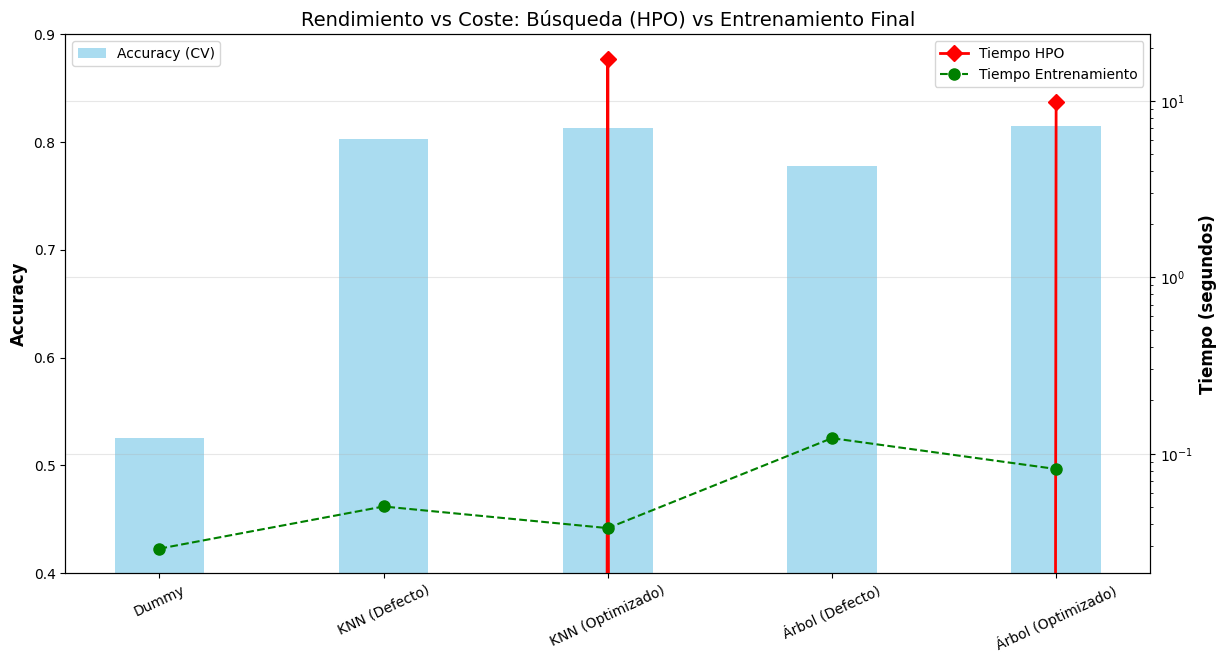

In [33]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

# Vamos a entrenar los modelos con los mejores HP para poder diferenciar el tiempo de entrenamiento del tiempo de HPO.
# KNN
start = time.time()
optuna_knn.best_estimator_.fit(X_train, y_train)
tiempo_refit_knn = time.time() - start

# Árbol
start = time.time()
optuna_tree.best_estimator_.fit(X_train, y_train)
tiempo_refit_tree = time.time() - start

# Dummy 
dummy_pipe = Pipeline(steps=[
    ('pre', preprocessor_std), 
    ('model', DummyClassifier(strategy='most_frequent'))
])

inicio_dummy = time.time()
dummy_pipe.fit(X_train, y_train)
tiempo_dummy = time.time() - inicio_dummy

dummy_scores = cross_val_score(dummy_pipe, X_train, y_train, cv=cv_inner, scoring='accuracy')
accuracy_dummy = dummy_scores.mean()


# Agrupamos toda la información para mostrarlo en la gráfica
datos_comparativa = [
    {
        "Modelo": "Dummy",
        "Accuracy": accuracy_dummy,
        "Tiempo HPO (s)": 0,
        "Tiempo Entrenamiento (s)": tiempo_dummy
    },
    {
        "Modelo": "KNN (Defecto)",
        "Accuracy": resultados_defecto['KNN']['accuracy'],
        "Tiempo HPO (s)": 0, # No tiene HPO
        "Tiempo Entrenamiento (s)": resultados_defecto['KNN']['tiempo']
    },
    {
        "Modelo": "KNN (Optimizado)",
        "Accuracy": optuna_knn.best_score_,
        "Tiempo HPO (s)": tiempo_knn, 
        "Tiempo Entrenamiento (s)": tiempo_refit_knn 
    },
    {
        "Modelo": "Árbol (Defecto)",
        "Accuracy": resultados_defecto['Árbol de Decisión']['accuracy'],
        "Tiempo HPO (s)": 0, # No tiene HPO
        "Tiempo Entrenamiento (s)": resultados_defecto['Árbol de Decisión']['tiempo']
    },
    {
        "Modelo": "Árbol (Optimizado)",
        "Accuracy": optuna_tree.best_score_,
        "Tiempo HPO (s)": tiempo_tree, 
        "Tiempo Entrenamiento (s)": tiempo_refit_tree 
    }
]

# Mostramos toda la información de manera visual
df_final = pd.DataFrame(datos_comparativa)
display(df_final.sort_values(by="Accuracy", ascending=False).reset_index(drop=True))

# Mostramos el gráfico para representar la información de manera visual
fig, ax1 = plt.subplots(figsize=(14, 7))

# Barras de Accuracy
x = range(len(df_final))
ax1.bar(x, df_final['Accuracy'], width=0.4, label='Accuracy (CV)', color='skyblue', alpha=0.7)
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_ylim(0.4, 0.9)
ax1.set_xticks(x)
ax1.set_xticklabels(df_final['Modelo'], rotation=25)

# Eje derecho para tiempos (en escala logarítmica porque la diferencia muy grande)
ax2 = ax1.twinx()
ax2.plot(x, df_final['Tiempo HPO (s)'], color='red', marker='D', markersize=8, label='Tiempo HPO', linewidth=2)
ax2.plot(x, df_final['Tiempo Entrenamiento (s)'], color='green', marker='o', markersize=8, label='Tiempo Entrenamiento', linestyle='--')

ax2.set_ylabel('Tiempo (segundos)', fontsize=12, fontweight='bold')
ax2.set_yscale('log') 

plt.title('Rendimiento vs Coste: Búsqueda (HPO) vs Entrenamiento Final', fontsize=14)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

Tras analizar los resultados obtenidos, podemos concluir que el Árbol de Decisión Optimizado es el mejor método de esta sección. Todos los modelos entrenados superan con creces al modelo Dummy, que establece una línea base de 52,55%. Esta diferencia de casi 30 puntos confirma que los algoritmos están capturando patrones reales de los datos y no prediciendo basándose únicamente en la frecuencia de las clases.

El ajuste de hiperparámetros (HPO) ha demostrado ser una buena inversión, aunque su impacto varía según el algoritmo. En el caso del Árbol de Decisión, la optimización permitió subir del 77,74% al 81,43%. Por el contrario, KNN mostró una mejora mucho más discreta (apenas un 2%), lo que sugiere que el Árbol de Decisión se adapta mejor a la naturaleza de este conjunto de datos.

Respecto al coste computacional, el tiempo de HPO es considerablemente elevado en comparación con los modelos por defecto. Sin embargo, este es un "coste de diseño" que se asume una sola vez. Una vez encontrados los parámetros óptimos, el tiempo de entrenamiento final del Árbol Optimizado es de apenas 0,086 segundos, y en KNN, sigue siendo pequeño ya que el entrenamiento de KNN se basa en simplemente almacenar los datos.

En conclusión, el incremento en el coste computacional durante la fase de optimización está plenamente justificado por la mejora en la precisión. El Árbol de Decisión optimizado no solo es el más preciso, sino que en términos de ejecución, resulta ser un modelo extremadamente ligero y rápido.